# Capstone course - final project

## Which of the five boroughs of New York City are most similar.

### Install geopy, folium, requests, and beautiful soup

In [6]:
!conda install -c conda-forge geopy --yes 
print("Installed geopy")

!conda install -c conda-forge folium=0.5.0 --yes 
print("Installed folium")

# Added yes when was asked to procced during request install
!conda install beautifulsoup4 --yes
print("Installed beautifulsoup4")

# Added yes when was asked to procced during request install
!conda install requests --yes
print("Installed requests")

print("Installations finished")

Solving environment: / 
The environment is inconsistent, please check the package plan carefully
The following packages are causing the inconsistency:

  - defaults/linux-64::anaconda==5.3.1=py37_0
  - defaults/linux-64::astropy==3.0.4=py37h14c3975_0
  - defaults/linux-64::bkcharts==0.2=py37_0
  - defaults/linux-64::blaze==0.11.3=py37_0
  - defaults/linux-64::bokeh==0.13.0=py37_0
  - defaults/linux-64::bottleneck==1.2.1=py37h035aef0_1
  - defaults/linux-64::dask==0.19.1=py37_0
  - defaults/linux-64::datashape==0.5.4=py37_1
  - defaults/linux-64::mkl-service==1.1.2=py37h90e4bf4_5
  - defaults/linux-64::numba==0.39.0=py37h04863e7_0
  - defaults/linux-64::numexpr==2.6.8=py37hd89afb7_0
  - defaults/linux-64::odo==0.5.1=py37_0
  - defaults/linux-64::pytables==3.4.4=py37ha205bf6_0
  - defaults/linux-64::pytest-arraydiff==0.2=py37h39e3cac_0
  - defaults/linux-64::pytest-astropy==0.4.0=py37_0
  - defaults/linux-64::pytest-doctestplus==0.1.3=py37_0
  - defaults/linux-64::pywavelets==1.0.0=py37h

# Import needed panadas, numpy, and others.

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

import json # library to handle JSON files
#!conda install -c conda-forge geopy --yes # uncomment this line if you haven't completed the Foursquare API lab
from geopy.geocoders import Nominatim # convert an address into latitude and longitude values

import requests # library to handle requests
from pandas.io.json import json_normalize # tranform JSON file into a pandas dataframe

# Matplotlib and associated plotting modules
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as mp

# import k-means from clustering stage
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import f1_score

import math

import requests

#!conda install -c conda-forge folium=0.5.0 --yes # uncomment this line if you haven't completed the Foursquare API lab
import folium # map rendering library

from bs4 import BeautifulSoup

import random # library for random number generation

from geopy.geocoders import Nominatim # module to convert an address into latitude and longitude values

# libraries for displaying images
from IPython.display import Image 
from IPython.core.display import HTML 

    
print('Libraries imported.')

Libraries imported.


### Read in the New York City Neighborhood coordinates we used in the course.
##### (Source: https://geo.nyu.edu/catalog/nyu_2451_34572)

In [2]:
!wget -q -O 'newyork_data.json' https://cocl.us/new_york_dataset
print('Data downloaded!')

with open('newyork_data.json') as json_data:
    newyork_data = json.load(json_data)

neighborhoods_data = newyork_data['features']


Data downloaded!


### Load the NYC neighborhood data into a pandas dataframe.

In [3]:

# define dataframe
neighborhoods = pd.DataFrame(columns= ['Borough', 'Neighborhood', 'Latitude', 'Longitude'])

# load data
for data in neighborhoods_data:
    neighborhoods= neighborhoods.append({'Borough': data['properties']['borough'] ,
                                          'Neighborhood': data['properties']['name'],
                                          'Latitude': data['geometry']['coordinates'][1],
                                          'Longitude': data['geometry']['coordinates'][0]}, ignore_index=True)
neighborhoods.head(5)   

,Borough,Neighborhood,Latitude,Longitude
0,Bronx,Wakefield,40.894705,-73.847201
1,Bronx,Co-op City,40.874294,-73.829939
2,Bronx,Eastchester,40.887556,-73.827806
3,Bronx,Fieldston,40.895437,-73.905643
4,Bronx,Riverdale,40.890834,-73.912585


### Check for unique rows.

In [4]:
print('Number unique Boroughs =', len(neighborhoods['Borough'].unique()))
print('Number unique neighborhoods =', len(neighborhoods['Neighborhood'].unique()))
print('Number of total rows=', neighborhoods.shape[0])

Number unique Boroughs = 5
Number unique neighborhoods = 302
Number of total rows= 306


### Note that four neighborhoods have non-unique names, i.e. more than one borough have neighborhoods with the same names.

In [5]:

nonunique = neighborhoods.groupby('Neighborhood').count().sort_values(by=['Borough'], ascending=False)
nonunique.head(5)

,Borough,Latitude,Longitude
Neighborhood,,,
Sunnyside,2,2,2
Chelsea,2,2,2
Murray Hill,2,2,2
Bay Terrace,2,2,2
Ozone Park,1,1,1


### Concatenate Neighborhood and Borough to ensure unique values for Neighborhood

In [6]:
dfn2=neighborhoods
dfn2.Neighborhood = dfn2.Neighborhood + ', ' + dfn2.Borough
print('Number unique Boroughs =', len(dfn2['Borough'].unique()))
print('Number unique neighborhoods =', len(dfn2['Neighborhood'].unique()))
print('Number of total rows=', neighborhoods.shape[0])
print('Number of rows now matches number of unique neighborhoods')
dfn2.head(5)

Number unique Boroughs = 5
Number unique neighborhoods = 306
Number of total rows= 306
Number of rows now matches number of unique neighborhoods


,Borough,Neighborhood,Latitude,Longitude
0,Bronx,"Wakefield, Bronx",40.894705,-73.847201
1,Bronx,"Co-op City, Bronx",40.874294,-73.829939
2,Bronx,"Eastchester, Bronx",40.887556,-73.827806
3,Bronx,"Fieldston, Bronx",40.895437,-73.905643
4,Bronx,"Riverdale, Bronx",40.890834,-73.912585


### Get the latitude and Longitude for New York, NY. for centering the map later on.

In [7]:

geolocator = Nominatim(user_agent="get_geo")
location = geolocator.geocode('New York, NY')
latitude = location.latitude
longitude = location.longitude
print('NYC Lat, Long:', latitude, longitude)
nyc_latitude = latitude
nyc_longitude = longitude


geolocator = Nominatim(user_agent="get_geo")
location = geolocator.geocode('Bronx, NY')
latitude = location.latitude
longitude = location.longitude
print('Bronx Lat, Long:', latitude, longitude)
Bronx_latitude = latitude
Bronx_longitude = longitude

geolocator = Nominatim(user_agent="get_geo")
location = geolocator.geocode('Brooklyn, NY')
latitude = location.latitude
longitude = location.longitude
print('Brooklyn Lat, Long:', latitude, longitude)
Brooklyn_latitude = latitude
Brooklyn_longitude = longitude

geolocator = Nominatim(user_agent="get_geo")
location = geolocator.geocode('Manhattan, NY')
latitude = location.latitude
longitude = location.longitude
print('Manhattan Lat, Long:', latitude, longitude)
Manhattan_latitude = latitude
Manhattan_longitude = longitude

geolocator = Nominatim(user_agent="get_geo")
location = geolocator.geocode('Queens, NY')
latitude = location.latitude
longitude = location.longitude
print('Queens Lat, Long:', latitude, longitude)
Queens_latitude = latitude
Queens_longitude = longitude

geolocator = Nominatim(user_agent="get_geo")
location = geolocator.geocode('Staten Island, NY')
latitude = location.latitude
longitude = location.longitude
print('Staten Island Lat, Long:', latitude, longitude)
Staten_Island_latitude = latitude
Staten_Island_longitude = longitude


NYC Lat, Long: 40.7308619 -73.9871558
Bronx Lat, Long: 40.85048545 -73.8404035580209
Brooklyn Lat, Long: 40.6501038 -73.9495823
Manhattan Lat, Long: 40.7900869 -73.9598295
Queens Lat, Long: 40.6524927 -73.7914214158161
Staten Island Lat, Long: 40.5834557 -74.1496048


In [8]:
Boro_lat_long_columns=['Borough', 'Latitude', 'Longitude']
Borough_Lat_Long = pd.DataFrame(columns = Boro_lat_long_columns)
Borough_Lat_Long.loc[len(Borough_Lat_Long)] = ['Bronx', Bronx_latitude, Bronx_longitude]
Borough_Lat_Long.loc[len(Borough_Lat_Long)] = ['Brooklyn', Brooklyn_latitude, Brooklyn_longitude]
Borough_Lat_Long.loc[len(Borough_Lat_Long)] = ['Manhattan', Manhattan_latitude, Manhattan_longitude]
Borough_Lat_Long.loc[len(Borough_Lat_Long)] = ['Queens', Queens_latitude, Queens_longitude]
Borough_Lat_Long.loc[len(Borough_Lat_Long)] = ['Staten Island', Staten_Island_latitude, Staten_Island_longitude]
Borough_Lat_Long

,Borough,Latitude,Longitude
0,Bronx,40.850485,-73.840404
1,Brooklyn,40.650104,-73.949582
2,Manhattan,40.790087,-73.959829
3,Queens,40.652493,-73.791421
4,Staten Island,40.583456,-74.149605


### Load the Forsquare iD info to access the Foursquare geo based info.

In [9]:
CLIENT_ID = 'HSW5E4TVOMC3UQFD0KPA0OFY41JHE0KTYLWRUIUVQUWGOKMN' # your Foursquare ID
CLIENT_SECRET = 'HZXQVYWM3E0OMVHKXSOAZ4DBMEFDVVCCVTRKPTA0E5N4PNPP' # your Foursquare Secret
VERSION = '20180604'
LIMIT = 30


##### Function learned in course for getting venues

In [13]:

def getNearbyVenues(names, borough, latitudes, longitudes, radius=500):
    
    venues_list=[]
    for name, borough, lat, lng in zip(names, borough, latitudes, longitudes):
        #print(name)
            
        # create the API request URL
        url = 'https://api.foursquare.com/v2/venues/explore?&client_id={}&client_secret={}&v={}&ll={},{}&radius={}&limit={}'.format(
            CLIENT_ID, 
            CLIENT_SECRET, 
            VERSION, 
            lat, 
            lng, 
            radius, 
            LIMIT)
            
        # make the GET request
        results = requests.get(url).json()["response"]['groups'][0]['items']
        
        # return only relevant information for each nearby venue
        venues_list.append([(
            name, 
            borough, 
            lat, 
            lng, 
            v['venue']['name'], 
            v['venue']['location']['lat'], 
            v['venue']['location']['lng'],  
            v['venue']['categories'][0]['name']) for v in results])

    nearby_venues = pd.DataFrame([item for venue_list in venues_list for item in venue_list])
    nearby_venues.columns = ['Neighborhood', 
                             'Borough',
                  'Neighborhood Latitude', 
                  'Neighborhood Longitude', 
                  'Venue', 
                  'Venue Latitude', 
                  'Venue Longitude', 
                  'Venue Category']
    
    return(nearby_venues)

# By pulling from the neighborhoods, can get a more representative sample.  It pulls data from meaningful sections of the borough, i.e. the neighborhoods.

##### Run the function to get the venues

In [14]:
nyc_venues = getNearbyVenues(names=dfn2['Neighborhood'],
                                borough= dfn2['Borough'],
                                 latitudes=dfn2['Latitude'],
                                 longitudes=dfn2['Longitude']
                                  )
print('Venues obtained')

Venues obtained


#### Examine the venues dataframe.

In [15]:
print(nyc_venues.shape)
nyc_venues.head(5)


(6147, 8)


,Neighborhood,Borough,Neighborhood Latitude,Neighborhood Longitude,Venue,Venue Latitude,Venue Longitude,Venue Category
0,"Wakefield, Bronx",Bronx,40.894705,-73.847201,Lollipops Gelato,40.894123,-73.845892,Dessert Shop
1,"Wakefield, Bronx",Bronx,40.894705,-73.847201,Rite Aid,40.896649,-73.844846,Pharmacy
2,"Wakefield, Bronx",Bronx,40.894705,-73.847201,Carvel Ice Cream,40.890487,-73.848568,Ice Cream Shop
3,"Wakefield, Bronx",Bronx,40.894705,-73.847201,Cooler Runnings Jamaican Restaurant Inc,40.898276,-73.850381,Caribbean Restaurant
4,"Wakefield, Bronx",Bronx,40.894705,-73.847201,Dunkin Donuts,40.890459,-73.849089,Donut Shop


### In another data set (Toronto), one of the values of Venue Category is Neighborhood, this causes get_dummies to make a variable called Neighborhood.  There is already a column called Neighborhood, so this causes there to be TWO columns with the same name: Neighborhood, in the same Dataframe.  This later prevents caluculations using groupby.
### To address this, Changed 'Venue Category' values of Neighborhood to 'Neighborhood Category', so that there would not be two columns with the same name.
### Therefore, to be safe, for this New York City data, will apply the same method and change any Venue Category with a value of 'Neighborhood' to 'Neighborhood Category'.

In [16]:
# If venue is "Neighborhood" then change to 'Neighborhood Category'
nyc_venues.loc[nyc_venues['Venue Category'] == 'Neighborhood', 'Venue Category'] = 'Neighborhood Category'


# Cluster by Borough
### K Means clustering expects numeric values; therefore, create numeric dummy variables.

In [17]:
dummies = pd.get_dummies(nyc_venues['Venue Category'])
dummies2 = pd.concat([nyc_venues['Borough'], dummies], axis=1)
#print(dummies2.columns)
#print(dummies2.shape)                
dummy_means = dummies2.groupby('Borough').mean().reset_index()
#print('dummy_means shape:' ,dummy_means.shape)
dummy_means.head(5)

,Borough,Accessories Store,Adult Boutique,Afghan Restaurant,African Restaurant,Airport Terminal,Airport Tram,American Restaurant,Antique Shop,Arcade,Arepa Restaurant,Argentinian Restaurant,Art Gallery,Art Museum,Arts & Crafts Store,Asian Restaurant,Athletics & Sports,Auditorium,Australian Restaurant,Austrian Restaurant,Automotive Shop,BBQ Joint,Baby Store,Bagel Shop,Bakery,Bank,Bar,Baseball Field,Baseball Stadium,Basketball Court,Beach,Beach Bar,Bed & Breakfast,Beer Bar,Beer Garden,Beer Store,Big Box Store,Bike Shop,Bike Trail,Bistro,Board Shop,Boat or Ferry,Bookstore,Boutique,Bowling Alley,Boxing Gym,Brazilian Restaurant,Breakfast Spot,Brewery,Bridal Shop,Bridge,Bubble Tea Shop,Buffet,Building,Burger Joint,Burrito Place,Bus Line,Bus Station,Bus Stop,Business Service,Butcher,Cafeteria,Café,Cajun / Creole Restaurant,Campground,Candy Store,Cantonese Restaurant,Caribbean Restaurant,Caucasian Restaurant,Check Cashing Service,Cheese Shop,Chinese Restaurant,Chocolate Shop,Church,Circus,Climbing Gym,Clothing Store,Cocktail Bar,Coffee Shop,College Academic Building,College Basketball Court,Colombian Restaurant,Comedy Club,Comfort Food Restaurant,Comic Shop,Community Center,Concert Hall,Construction & Landscaping,Convenience Store,Cosmetics Shop,Creperie,Cuban Restaurant,Cupcake Shop,Cycle Studio,Czech Restaurant,Dance Studio,Deli / Bodega,Department Store,Design Studio,Dessert Shop,Dim Sum Restaurant,Diner,Discount Store,Distillery,Dive Bar,Dog Run,Donut Shop,Dry Cleaner,Dumpling Restaurant,Duty-free Shop,Eastern European Restaurant,Egyptian Restaurant,Electronics Store,Empanada Restaurant,English Restaurant,Ethiopian Restaurant,Event Service,Event Space,Eye Doctor,Factory,Falafel Restaurant,Farm,Farmers Market,Fast Food Restaurant,Field,Filipino Restaurant,Fish & Chips Shop,Fish Market,Flower Shop,Food,Food & Drink Shop,Food Court,Food Truck,Fountain,French Restaurant,Fried Chicken Joint,Frozen Yogurt Shop,Fruit & Vegetable Store,Furniture / Home Store,Gaming Cafe,Garden,Garden Center,Gas Station,Gastropub,Gay Bar,General Entertainment,German Restaurant,Gift Shop,Gluten-free Restaurant,Golf Course,Gourmet Shop,Greek Restaurant,Grocery Store,Gym,Gym / Fitness Center,Gymnastics Gym,Halal Restaurant,Harbor / Marina,Hardware Store,Hawaiian Restaurant,Health & Beauty Service,Health Food Store,Heliport,High School,Himalayan Restaurant,Historic Site,History Museum,Hobby Shop,Home Service,Hookah Bar,Hostel,Hot Dog Joint,Hotel,Hotel Bar,Hotpot Restaurant,IT Services,Ice Cream Shop,Indian Restaurant,Indie Movie Theater,Indie Theater,Indonesian Restaurant,Insurance Office,Intersection,Irish Pub,Israeli Restaurant,Italian Restaurant,Japanese Curry Restaurant,Japanese Restaurant,Jazz Club,Jewelry Store,Jewish Restaurant,Juice Bar,Karaoke Bar,Kids Store,Korean Restaurant,Kosher Restaurant,Lake,Latin American Restaurant,Laundromat,Laundry Service,Lawyer,Leather Goods Store,Lebanese Restaurant,Library,Lingerie Store,Liquor Store,Lounge,Malay Restaurant,Market,Martial Arts Dojo,Massage Studio,Mattress Store,Medical Center,Mediterranean Restaurant,Memorial Site,Men's Store,Metro Station,Mexican Restaurant,Middle Eastern Restaurant,Mini Golf,Miscellaneous Shop,Mobile Phone Shop,Molecular Gastronomy Restaurant,Monument / Landmark,Moroccan Restaurant,Motel,Motorcycle Shop,Movie Theater,Moving Target,Multiplex,Museum,Music School,Music Store,Music Venue,Nail Salon,Neighborhood Category,New American Restaurant,Newsstand,Nightclub,Nightlife Spot,Non-Profit,Noodle House,North Indian Restaurant,Opera House,Optical Shop,Organic Grocery,Other Great Outdoors,Other Nightlife,Other Repair Shop,Outdoor Sculpture,Outdoors & Recreation,Paella Restaurant,Pakistani Restaurant,Paper / Office Supplies Store,Park,Pedestrian Plaza,Performing Arts Venue,Peruvian Restaurant,Pet Café,Pet Service,Pet Store,Pharmacy,Pie Shop,Pier,Pilates Studio,Pizza Place,Platform,Playground,Plaza,Polish Restaurant,Pool,Pool Hall,Print Shop,Pub,Public Art,Racetrack,Ramen Restaurant,Record Shop

# Get most common venues per borough

In [18]:
#  use functions kearned in the course work
def return_most_common_venues(row, num_top_venues):
    row_categories = row.iloc[1:]
    row_categories_sorted = row_categories.sort_values(ascending=False)
    
    return row_categories_sorted.index.values[0:num_top_venues]


number_top_venues_for_clustering = 10

# Start with Borouugh and then add a column for eacn fo the top venues types 
columns = ['Borough']
for ind in np.arange(number_top_venues_for_clustering):
    columns.append('Number_{}_Venue_Type'.format(ind+1))

# create a new dataframe, note that coumns now contains multiple columns
#print('columns=',columns)
Boroughs_venues_sorted = pd.DataFrame(columns=columns)
Boroughs_venues_sorted['Borough'] = dummy_means['Borough']

for ind in np.arange(dummy_means.shape[0]):
    Boroughs_venues_sorted.iloc[ind, 1:] = return_most_common_venues(dummy_means.iloc[ind, :], number_top_venues_for_clustering)

Boroughs_venues_sorted.head(5)

,Borough,Number_1_Venue_Type,Number_2_Venue_Type,Number_3_Venue_Type,Number_4_Venue_Type,Number_5_Venue_Type,Number_6_Venue_Type,Number_7_Venue_Type,Number_8_Venue_Type,Number_9_Venue_Type,Number_10_Venue_Type
0,Bronx,Pizza Place,Deli / Bodega,Supermarket,Pharmacy,Chinese Restaurant,Donut Shop,Bus Station,Sandwich Place,Italian Restaurant,Spanish Restaurant
1,Brooklyn,Pizza Place,Coffee Shop,Bar,Italian Restaurant,Grocery Store,Café,Deli / Bodega,Bakery,Ice Cream Shop,Pharmacy
2,Manhattan,Coffee Shop,Park,American Restaurant,Italian Restaurant,Café,Bakery,Pizza Place,Cocktail Bar,Gym,Spa
3,Queens,Pizza Place,Deli / Bodega,Chinese Restaurant,Bakery,Pharmacy,Donut Shop,Bank,Italian Restaurant,Sandwich Place,Bus Station
4,Staten Island,Pizza Place,Bus Stop,Deli / Bodega,Italian Restaurant,Bagel Shop,Pharmacy,Sandwich Place,Bank,Grocery Store,Chinese Restaurant


## Show K Means "Elbow" graph.
### For different cluster number graph the sum of the squared errors, i.e. distance to closest cluster center (which kmeans outputs as inertia_).

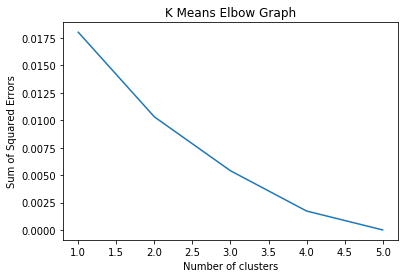

In [19]:

dummy_means_clustering = dummy_means.drop('Borough', 1)
cluster_range = range(1, 6)
sse = {}
#kmeans = [KMeans(n_clusters=i, init='random') for i in Nc]
for i in cluster_range:
    #km=KMeans(n_clusters=i, init='random')
    km=KMeans(n_clusters=i, random_state=0)
    km.fit(dummy_means_clustering)
    labels = km.labels_
    dummy_means['Cluster Labels'] = labels
    #print('Allowing ', i, 'clusters:')
    #print(dummy_means.groupby(['Borough', 'Cluster Labels']).size())
    sse[i] = km.inertia_ 

mp.figure()
mp.title('K Means Elbow Graph')
mp.plot(list(sse.keys()), list(sse.values()))
mp.xlabel("Number of clusters")
mp.ylabel("Sum of Squared Errors")
mp.show()

## The K means Elbow graph suggests at least four clusters; however, with only five boroughs to cluster, four clusters would not do a good job of showing which boroughs are most similar. 
#### Four clusters would come close to putting each borough in its own cluster (kept for one case).
## We will use three clusters, as this seems most appropriate for the purpose of showing which boroughs are similar.  

In [20]:
# note: if rerunning this code, then first need to go back and rerun the section above that creates the dummy variables and then run each seciton.
number_of_clusters = 3
km=KMeans(n_clusters=number_of_clusters, random_state=0)
km.fit(dummy_means_clustering)
labels = km.labels_

# Borough level clusters
# merge the clusters data with data prior to clusting to each Borough name
Boroughs_venues_sorted.insert(0, 'Cluster Labels', km.labels_)
# get the data prior to clustering
data_merged = dfn2

# Adding neighborhood level rows for map
# merge the clusters data with data prior to clusting to add latitude/longitude for each neighborhood
data_merged = data_merged.join(Boroughs_venues_sorted.set_index('Borough'), on='Borough')

dummy_means['Cluster Labels'] = labels
# Show the Boroughs, thier clusters, and the number of neighborhoods
data_merged.groupby(['Borough', 'Cluster Labels']).size()

Borough        Cluster Labels
Bronx          0                 52
Brooklyn       1                 70
Manhattan      1                 40
Queens         0                 81
Staten Island  2                 63
dtype: int64

In [21]:
Boroughs_venues_sorted

,Cluster Labels,Borough,Number_1_Venue_Type,Number_2_Venue_Type,Number_3_Venue_Type,Number_4_Venue_Type,Number_5_Venue_Type,Number_6_Venue_Type,Number_7_Venue_Type,Number_8_Venue_Type,Number_9_Venue_Type,Number_10_Venue_Type
0,0,Bronx,Pizza Place,Deli / Bodega,Supermarket,Pharmacy,Chinese Restaurant,Donut Shop,Bus Station,Sandwich Place,Italian Restaurant,Spanish Restaurant
1,1,Brooklyn,Pizza Place,Coffee Shop,Bar,Italian Restaurant,Grocery Store,Café,Deli / Bodega,Bakery,Ice Cream Shop,Pharmacy
2,1,Manhattan,Coffee Shop,Park,American Restaurant,Italian Restaurant,Café,Bakery,Pizza Place,Cocktail Bar,Gym,Spa
3,0,Queens,Pizza Place,Deli / Bodega,Chinese Restaurant,Bakery,Pharmacy,Donut Shop,Bank,Italian Restaurant,Sandwich Place,Bus Station
4,2,Staten Island,Pizza Place,Bus Stop,Deli / Bodega,Italian Restaurant,Bagel Shop,Pharmacy,Sandwich Place,Bank,Grocery Store,Chinese Restaurant


Add Borough latitude and longitude.

In [22]:
Boroughs_venues_sorted2 = pd.merge(left=Boroughs_venues_sorted, right=Borough_Lat_Long, on='Borough')
Boroughs_venues_sorted2

,Cluster Labels,Borough,Number_1_Venue_Type,Number_2_Venue_Type,Number_3_Venue_Type,Number_4_Venue_Type,Number_5_Venue_Type,Number_6_Venue_Type,Number_7_Venue_Type,Number_8_Venue_Type,Number_9_Venue_Type,Number_10_Venue_Type,Latitude,Longitude
0,0,Bronx,Pizza Place,Deli / Bodega,Supermarket,Pharmacy,Chinese Restaurant,Donut Shop,Bus Station,Sandwich Place,Italian Restaurant,Spanish Restaurant,40.850485,-73.840404
1,1,Brooklyn,Pizza Place,Coffee Shop,Bar,Italian Restaurant,Grocery Store,Café,Deli / Bodega,Bakery,Ice Cream Shop,Pharmacy,40.650104,-73.949582
2,1,Manhattan,Coffee Shop,Park,American Restaurant,Italian Restaurant,Café,Bakery,Pizza Place,Cocktail Bar,Gym,Spa,40.790087,-73.959829
3,0,Queens,Pizza Place,Deli / Bodega,Chinese Restaurant,Bakery,Pharmacy,Donut Shop,Bank,Italian Restaurant,Sandwich Place,Bus Station,40.652493,-73.791421
4,2,Staten Island,Pizza Place,Bus Stop,Deli / Bodega,Italian Restaurant,Bagel Shop,Pharmacy,Sandwich Place,Bank,Grocery Store,Chinese Restaurant,40.583456,-74.149605


## The clustering has grouped:
#### 1. Brooklyn and Manhattan
#### 2. Bronx and Queens
#### 3. Staten Island

In [23]:
#data_merged.groupby('Borough', 'Cluster Labels', axis=1).unique()
#data_merged.groupby(['Borough', 'Cluster Labels']).size()
Boroughs_venues_sorted2.groupby(['Borough', 'Cluster Labels']).size()

Borough        Cluster Labels
Bronx          0                 1
Brooklyn       1                 1
Manhattan      1                 1
Queens         0                 1
Staten Island  2                 1
dtype: int64

### Create choropleth map to visualize clusters, clustered by borough, showing the neighborhoods within the boroughs.

# Show each cluster with its most common venue categories

In [24]:
Boroughs_venues_sorted2

,Cluster Labels,Borough,Number_1_Venue_Type,Number_2_Venue_Type,Number_3_Venue_Type,Number_4_Venue_Type,Number_5_Venue_Type,Number_6_Venue_Type,Number_7_Venue_Type,Number_8_Venue_Type,Number_9_Venue_Type,Number_10_Venue_Type,Latitude,Longitude
0,0,Bronx,Pizza Place,Deli / Bodega,Supermarket,Pharmacy,Chinese Restaurant,Donut Shop,Bus Station,Sandwich Place,Italian Restaurant,Spanish Restaurant,40.850485,-73.840404
1,1,Brooklyn,Pizza Place,Coffee Shop,Bar,Italian Restaurant,Grocery Store,Café,Deli / Bodega,Bakery,Ice Cream Shop,Pharmacy,40.650104,-73.949582
2,1,Manhattan,Coffee Shop,Park,American Restaurant,Italian Restaurant,Café,Bakery,Pizza Place,Cocktail Bar,Gym,Spa,40.790087,-73.959829
3,0,Queens,Pizza Place,Deli / Bodega,Chinese Restaurant,Bakery,Pharmacy,Donut Shop,Bank,Italian Restaurant,Sandwich Place,Bus Station,40.652493,-73.791421
4,2,Staten Island,Pizza Place,Bus Stop,Deli / Bodega,Italian Restaurant,Bagel Shop,Pharmacy,Sandwich Place,Bank,Grocery Store,Chinese Restaurant,40.583456,-74.149605


# Labeling the clusters
#### 1. Brooklyn and Manhattan (Coffee Shop)
#### 2. Bronx and Queens (Pizza Place and Deli / Bodega)
#### 3. Staten Island (Pizza Place and Bustop)

### Create labels based on clusters and most common venues in clusters.

In [25]:

label_columns=['Cluster Labels', 'Cluster_Name']
labels_df = pd.DataFrame(columns =label_columns)
labels_df.loc[len(labels_df)] = [0, 'Bronx and Queens (Pizza Place and Deli / Bodega)']
labels_df.loc[len(labels_df)] = [1, 'Brooklyn and Manhattan (Coffee Shop)']
labels_df.loc[len(labels_df)] = [2, 'Staten Island (Pizza Place and Bustop)']
labels_df


,Cluster Labels,Cluster_Name
0,0,Bronx and Queens (Pizza Place and Deli / Bodega)
1,1,Brooklyn and Manhattan (Coffee Shop)
2,2,Staten Island (Pizza Place and Bustop)


### Added cluster names to dataframe.

In [26]:

Boroughs2 = pd.merge(left=labels_df, right=Boroughs_venues_sorted2, on='Cluster Labels')
Boroughs2

,Cluster Labels,Cluster_Name,Borough,Number_1_Venue_Type,Number_2_Venue_Type,Number_3_Venue_Type,Number_4_Venue_Type,Number_5_Venue_Type,Number_6_Venue_Type,Number_7_Venue_Type,Number_8_Venue_Type,Number_9_Venue_Type,Number_10_Venue_Type,Latitude,Longitude
0,0,Bronx and Queens (Pizza Place and Deli / Bodega),Bronx,Pizza Place,Deli / Bodega,Supermarket,Pharmacy,Chinese Restaurant,Donut Shop,Bus Station,Sandwich Place,Italian Restaurant,Spanish Restaurant,40.850485,-73.840404
1,0,Bronx and Queens (Pizza Place and Deli / Bodega),Queens,Pizza Place,Deli / Bodega,Chinese Restaurant,Bakery,Pharmacy,Donut Shop,Bank,Italian Restaurant,Sandwich Place,Bus Station,40.652493,-73.791421
2,1,Brooklyn and Manhattan (Coffee Shop),Brooklyn,Pizza Place,Coffee Shop,Bar,Italian Restaurant,Grocery Store,Café,Deli / Bodega,Bakery,Ice Cream Shop,Pharmacy,40.650104,-73.949582
3,1,Brooklyn and Manhattan (Coffee Shop),Manhattan,Coffee Shop,Park,American Restaurant,Italian Restaurant,Café,Bakery,Pizza Place,Cocktail Bar,Gym,Spa,40.790087,-73.959829
4,2,Staten Island (Pizza Place and Bustop),Staten Island,Pizza Place,Bus Stop,Deli / Bodega,Italian Restaurant,Bagel Shop,Pharmacy,Sandwich Place,Bank,Grocery Store,Chinese Restaurant,40.583456,-74.149605


## Show a map of the clusters

In [27]:
#Use function learned in course.
# create map
map_clusters = folium.Map(location=[nyc_latitude, nyc_longitude], zoom_start=10)

# set color scheme for the clusters
x = np.arange(number_of_clusters)
ys = [i + x + (i*x)**2 for i in range(number_of_clusters)]
colors_array = cm.rainbow(np.linspace(0, 1, len(ys)))
rainbow = [colors.rgb2hex(i) for i in colors_array]

# add markers to the map
markers_colors = []
for lat, lon, poi, cluster, Cluster_Name in zip(Boroughs2['Latitude'], \
                                       Boroughs2['Longitude'], \
                                       Boroughs2['Borough'], \
                                       Boroughs2['Cluster Labels'], \
                                       Boroughs2['Cluster_Name']       ):

    label = folium.Popup(Cluster_Name , parse_html=True)
    folium.CircleMarker(
        [lat, lon],
        radius=30,
        popup=label,
        color=rainbow[cluster-1],
        fill=True,
        fill_color=rainbow[cluster-1],
        fill_opacity=0.7).add_to(map_clusters)
       
map_clusters

##### Note in the above choropleth Staten Island is light green, Manhattan and Brooklyn are red, and the Bronx and Queens are purple.